# Module 02: A Box Model of Land-Atmosphere Carbon Balance

### 1. Introduction


In [51]:
import numpy as np
import matplotlib.pyplot as plt

M1i = 1100.0
M2i = 300.0

k12 = 0.0003 
k21 = 0.1

ti = 0.0
tf = 100.0
dt = 1/365


In [52]:
t = np.arange(ti,tf+dt,dt)

Nt = t.size

print('t has '+str(Nt)+' time steps')

t has 36501 time steps


In [53]:
M1 = np.zeros((Nt,)) #creates empty space for our model to fill 
M2 = np.zeros((Nt,))

In [54]:
for i in np.arange(Nt):
    if (i==0):

        M1[i] = M1i #setting initial land and atmospheric carbon mass values for first time step
        M2[i] = M2i
        
    else:
        dM1dt = k21*M2[i-1] - k12*M1[i-1]*M2[i-1] #calculating the change in land carbon mass for each time step
        dM2dt = k12*M1[i-1]*M2[i-1] - k21*M2[i-1] #calculating the change in atmospheric carbon mass for each time step
        
        M1[i] = M1[i-1] + dM1dt*dt #subtracting the chnange in carbon mass from the previous time step to get the current mass of carbon 
        M2[i] = M2[i-1] + dM2dt*dt


In [60]:
M1_anlt = (k21*(M1i+M2i))/(k12+k21) + (k12*M1i - k21*M2i)/(k12+k21)*np.exp(-(k12+k21)*t) 
M2_anlt = (k12*(M1i+M2i))/(k12+k21) - (k12*M1i - k21*M2i)/(k12+k21)*np.exp(-(k12+k21)*t)

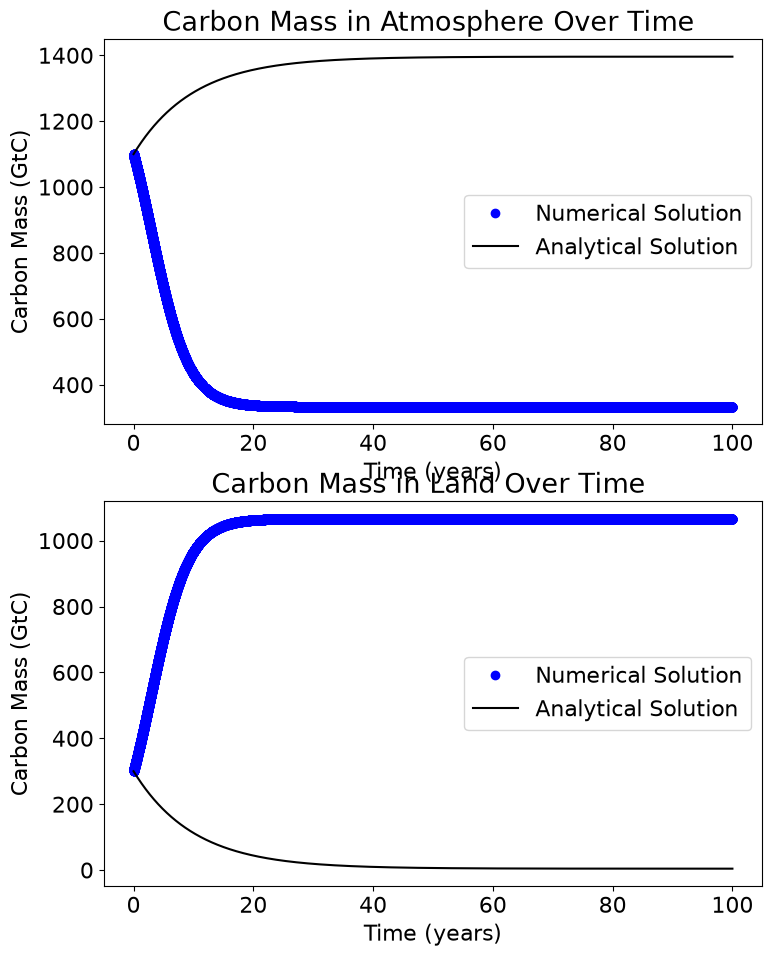

In [61]:
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Mass in Atmosphere Over Time ')
plt.plot(t,M1,'bo', label='Numerical Solution')
plt.plot(t,M1_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()


plt.subplot(2,1,2)
plt.title('Carbon Mass in Land Over Time ')
plt.plot(t,M2,'bo', label='Numerical Solution')
plt.plot(t,M2_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Carbon Mass (GtC)')
plt.legend()

plt.show()